# PROC KRIGE2D를 활용한 의료권역 응급실 대기시간의 공간 예측


## 요약

한 의료 시스템 네트워크 운영팀은 대도시 의료권역 내 모든 상시 운영 시설의 평균 응급실(ED) 대기시간(분)을 측정하고, 신규 응급진료소 부지의 서비스 취약 지역을 파악하기 위한 연속적인 대기시간 표면을 원한다. 이 노트북은 **지오코딩된 시설 90곳**의 합성 데이터셋을 생성하고, 너깃을 포함한 **정규 크리깅(ordinary-kriging)** 모델을 적합한 뒤, 50km x 50km 권역 전체에 걸친 정규 격자 위에 응급실 대기시간을 보간하여 모든 격자점과 제안된 응급진료소 후보지 3곳에서 점 예측값과 크리깅 표준오차를 산출한다.

시설 90곳 전체에서 관측된 대기시간은 평균 **35.5분**(범위 7.5~58.7)이다. 크리깅된 표면은 이 중심값을 거의 정확히 재현하며(격자점 평균 **35.55분**), 한산한 남동부의 **16.1**분부터 혼잡한 북서부의 **56.4**분까지 분포하는데, 예측 대기시간이 높은 격자점들은 도심 급증 구간 주변에 몰려 있다. 응급진료소 후보지 3곳 중 도심 핵심지역에 가장 가까운 곳이 가장 높은 대기시간(**52.2 +/- 7.3분**)을 예측하여, 가장 근거가 탄탄한 입지 후보가 된다.

## 데이터 소스

모든 데이터는 합성 데이터이며 첫 번째 DATA 스텝(`call streaminit(20260531)`)에서 인라인으로 생성된다. 외부 파일이나 네트워크 파일은 사용하지 않는다.

| 데이터셋 | 행 수 | 변수 | 유형 | 설명 |
|---------|------|----------|------|-------------|
| `ed_sites` | 90 | `east` | 수치형 | 대도시 권역 격자 내 시설의 동서 좌표(km, 0-50) |
| `ed_sites` | 90 | `north` | 수치형 | 대도시 권역 격자 내 시설의 남북 좌표(km, 0-50) |
| `ed_sites` | 90 | `site_id` | 문자형 | 시설 식별자 (예: `FAC037`) |
| `ed_sites` | 90 | `wait_min` | 수치형 | 관측된 평균 응급실 대기시간(분). 북서-남동 혼잡도 기울기, 도심 급증, 국소 노이즈를 결합한 공간적으로 상관된 표면 |

## PROC KRIGE2D를 활용한 응급실 대기시간의 공간 예측

한 지역 의료 시스템은 50km x 50km 대도시 권역 곳곳에 흩어진 **응급실과 응급진료소**를 운영한다. 각 시설은 **평균 응급실 대기시간**(분)을 보고한다. 대기시간은 공간적으로 상관되어 있다. 혼잡한 북서부 도심은 대기시간이 높고, 주변부 남동부 시설은 낮다. 네트워크 기획팀은 신규 응급진료소가 가장 큰 부담을 완화할 수 있는 취약 지역을 찾기 위해 불확실성까지 포함한 *연속적인* 대기시간 표면을 원한다.

**PROC KRIGE2D**는 2차원 정규 크리깅을 수행한다. 세미배리오그램 모델을 사용하여 측정된 대기시간을 위치 격자 위로 보간하며, 모든 격자점에서 예측값과 크리깅 표준오차를 함께 반환한다. 다음 순서로 진행한다.

1. 현실적인 합성 시설 데이터셋을 생성한다.
2. 관측된 대기시간 분포를 프로파일링한다.
3. 구형 모델과 너깃으로 크리깅하고 표면을 살펴본다.
4. 후보 응급진료소 위치 3곳에서 직접 예측한다.

## 1단계 - 합성 시설 데이터 생성

권역 전체에 시설 90곳을 균등하게 배치한다. 바탕에 깔린 '실제' 대기시간 표면은 완만한 대규모 추세(북서-남동 혼잡도 기울기에 (15, 38) 부근의 중앙 도심 융기를 더한 것)와 완만한 지역적 소용돌이를 결합하여, 순수한 노이즈가 아니라 실제로 공간적 자기상관을 갖는 필드가 되도록 한다. 일별 보고 편차를 흉내내기 위해 작은 측정 너깃도 추가한다.

In [1]:
데이터 ed_sites;
   호출 streaminit(20260531);
   길이 site_id $6;
   반복 i = 1 까지 90;
      east  = 50 * rand('uniform');
      north = 50 * rand('uniform');

      /* 대규모 혼잡도 추세: 북서쪽 도심에서 높고
         남동쪽 교외로 갈수록 감소 */
      trend = 18
            + 0.32 * (50 - east)
            + 0.28 * north;

      /* (15, 38) 부근을 중심으로 하는 도심 급증 구간 */
      dist2 = (east - 15)**2 + (north - 38)**2;
      surge = 22 * EXP(-dist2 / 160);

      /* 현실적인 공간 자기상관을 만들기 위한 완만한 지역적 소용돌이 */
      eddy  = 6 * sin(east/9) * cos(north/11);

      /* 일별 보고 편차를 흉내내는 국소 측정 노이즈(너깃) */
      noise = 4 * rand('normal');

      wait_min = round(trend + surge + eddy + noise, 0.1);
      만약 wait_min < 3 이면 wait_min = 3;

      site_id = cats('FAC', PUT(i, z3.));
      출력;
   종료;
   유지 site_id east north wait_min;
실행;

처리 인쇄 데이터=ed_sites(obs=10) noobs 라벨;
   제목 "합성 응급실 시설 상위 10건 (km 좌표, 대기시간은 분 단위)";
   변수 site_id east north wait_min;
   라벨 site_id  = "시설 ID"
         east     = "동서 좌표(km)"
         north    = "남북 좌표(km)"
         wait_min = "대기 시간(분)";
실행;


                                          합성 응급실 시설 상위 10건 (km 좌표, 대기시간은 분 단위)                                          

    시설 ID          동서 좌표(km)          남북 좌표(km)            대기 시간(분)
FAC001         42.1064239035      44.8746335392                36.7
FAC002         10.6189061789      14.5101311244                36.2
FAC003         48.9064287162        18.61727984                17.7
FAC004          45.555283186       43.264675772                34.5
FAC005         32.9816533373      24.7120124541                32.5
FAC006         31.1796232687      19.1168441231                31.4
FAC007         34.6664652019      35.2149577448                39.2
FAC008         40.5104234712       2.9588781811                17.1
FAC009          9.9213354522      40.5368804705                54.3
FAC010         24.5041747799      22.5897811072                35.9

... 80 more observations (showing 10 of 90)




NOTE: DATA ed_sites


NOTE: Wrote ed_sites (90 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC PRINT data=ed_sites

NOTE: PROC PRINT completed: 10 observations printed, 4 variables


## 2단계 - 관측 대기시간 프로파일링

크리깅에 앞서 표면이 합리적으로 분포되어 있는지 확인한다. 간단한 `PROC MEANS` 요약은 크리깅된 표면이 재현해야 할 범위와 중심경향을 알려준다. 시설 90곳은 평균 **35.5분**, 표준편차 **10.6**이며, 가장 한산한 교외 시설의 **7.5분**부터 가장 혼잡한 도심 시설의 **58.7분**까지 분포한다 - 보간 대상으로서 현실적으로 폭넓은 분포다.

In [2]:
처리 평균 데이터=ed_sites n mean std MIN p25 MEDIAN p75 MAX maxdec=1;
   제목 "시설별 관측 응급실 대기시간 분포";
   변수 wait_min;
   라벨 wait_min = "대기 시간(분)";
실행;


                                                   시설별 관측 응급실 대기시간 분포                                                   

                                                  The MEANS Procedure

 Variable  Label                     N        Mean     Std Dev     Minimum   Lower Quartile      Median   Upper Quartile     Maximum
 -----------------------------------------------------------------------------------------------------------------------------------
 wait_min  대기 시간(분)                 90        35.5        10.6         7.5             29.1        35.7             39.5        58.7
 -----------------------------------------------------------------------------------------------------------------------------------




NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## 3단계 - 구형 모델을 이용한 정규 크리깅

`COORDINATES` 문은 공간 축의 이름을 지정하고, `PREDICT VAR=`는 분석 변수를 지정하며 탐색 근린을 설정하고, `MODEL`은 세미배리오그램을 제공한다. 상관관계가 유한한 범위에서 0으로 사그라들 때 표준적으로 선택하는 **구형(spherical)** 형태를 사용하며, 값은 다음과 같다.

- `SCALE=120` - 부분 실(partial sill, 공간 구조로 설명되는 분산)
- `RANGE=18` - 상관관계가 약 18km에서 배경 수준에 도달
- `NUGGET=14` - 거리 0에서의 측정/보고 불연속성

전체 권역을 아우르는 정규 **9 x 9 = 81개 격자점**(`GRID X=0 TO 50 BY 6 Y=0 TO 50 BY 6`)으로 보간한다 - 모든 격자점을 직접 요약·순위화할 만큼 성기면서도 구조를 지도화할 만큼 촘촘하다. `OUTEST=`는 격자화된 예측값과 표준오차를 담아내고, `OUTNBHD=`는 각 국소 해에 몇 개의 시설이 들어갔는지 기록한다. `PLOTS=`는 관측 데이터 지도와 표준오차로 채운 예측 등고선을 요청한다.

                                                   시설별 관측 응급실 대기시간 분포                                                   

   The KRIGE2D Procedure    
     Model Information      

Item                   Value
-----------------  ---------
Variogram Model    SPHERICAL
Kriging Method      ORDINARY
Observations Used         90
Prediction Points         81




NOTE: PROC KRIGE2D: Two-Dimensional Kriging
NOTE: Using Python scipy version 1.16.3
NOTE: PROC KRIGE2D results written to: ./ods_output/krige2d_results.json
NOTE: Wrote krige_sph (81 rows, 4 columns).


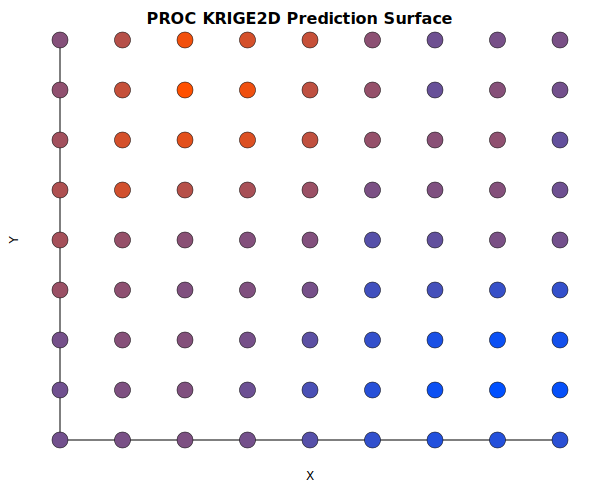

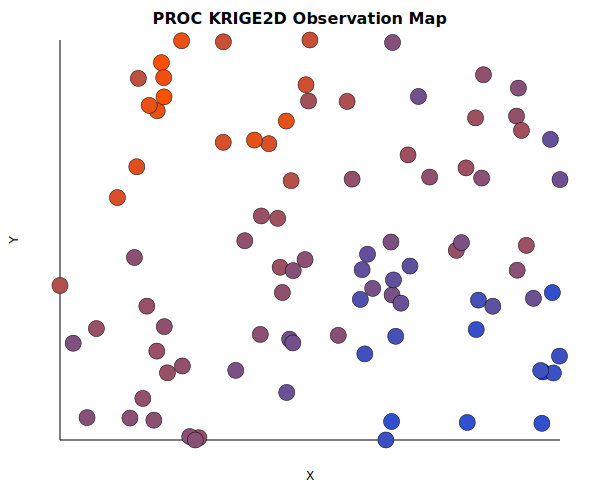

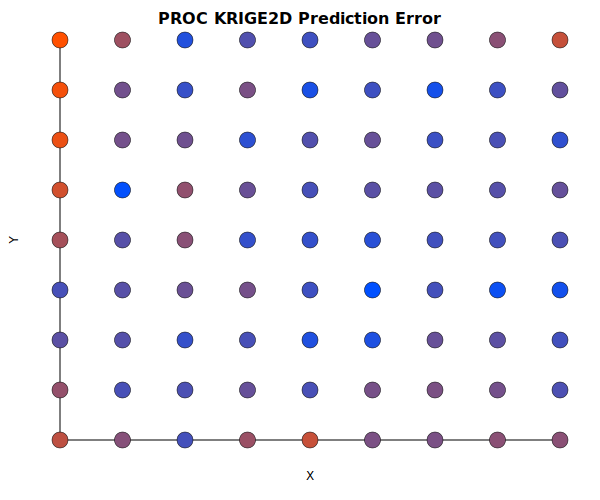

In [3]:
처리 krige2d 데이터=ed_sites outest=krige_sph outnbhd=nbhd_sph
      PLOTS(only)=(observations prediction(fill=pred line=se));
   제목 "응급실 대기시간의 정규 크리깅 - 구형 모델";
   COORDINATES XC=east YC=north;
   predict 변수=wait_min radius=20 minpoints=10 maxpoints=40;
   모형 FORM=spherical SCALE=120 range=18 NUGGET=14;
   grid x=0 까지 50 기준 6 y=0 까지 50 기준 6;
실행;


## 4단계 - 크리깅된 표면 살펴보기

`OUTEST=` 데이터셋은 격자점마다 한 행씩 예측 대기시간(`estimate`)과 크리깅 표준오차(`stderr`)를 담고 있다. 표면을 요약하고 예측값이 가장 높은 격자점 - 신규 응급진료소가 가장 큰 부담을 완화할 후보 지역 - 을 표시한다.

크리깅된 표면 평균(**35.55분**)은 관측 시설 평균(35.5)을 거의 정확히 따라가며, 이는 정규 크리깅이 비편향적임을 확인하는 검증이다. 예측값은 희소한 남동부의 **16.1**부터 혼잡한 북서부의 **56.4**까지 분포하며, 표준오차는 시설이 밀집한 곳의 **5.1**부터 표본이 희박한 모서리의 **11.2**까지 나타난다. 예측값이 가장 높은 격자점 6곳은 모두 (12-18, 36-48) 부근의 북서 사분면에 있으며, 이는 데이터에 내장된 도심 급증 구간과 정확히 일치한다.

In [4]:
처리 평균 데이터=krige_sph n mean MIN MAX maxdec=2;
   제목 "크리깅 표면 요약 (예측 대기시간 및 표준오차)";
   변수 estimate stderr;
   라벨 estimate = "예측 대기시간(분)"
         stderr   = "표준오차";
실행;

처리 정렬 데이터=krige_sph out=hot_nodes;
   기준 DESCENDING estimate;
실행;

처리 인쇄 데이터=hot_nodes(obs=6) noobs 라벨;
   제목 "예측 응급실 대기시간이 가장 높은 격자점 6곳";
   변수 x y estimate stderr;
   라벨 x        = "동서 좌표(km)"
         y        = "남북 좌표(km)"
         estimate = "예측 대기시간(분)"
         stderr   = "표준오차";
실행;


                                               크리깅 표면 요약 (예측 대기시간 및 표준오차)                                               

                                                  The MEANS Procedure

 Variable  Label                           N        Mean     Minimum     Maximum
 -------------------------------------------------------------------------------
 ESTIMATE  예측 대기시간(분)                     81       35.55       16.07       56.38
 STDERR    표준오차                           81        7.38        5.06       11.20
 -------------------------------------------------------------------------------

                                               예측 응급실 대기시간이 가장 높은 격자점 6곳                                                

        동서 좌표(km)          남북 좌표(km)                예측 대기시간(분)          표준오차
               12                 42             56.3838526129  6.3860887297
               12                 48              54.379464215   5.876759721
               18                 42            


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC SORT data=krige_sph

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 81 rows from krige_sph.
NOTE: Wrote hot_nodes (81 rows, 4 columns).
NOTE: PROC SORT statement used.
NOTE: PROC PRINT data=hot_nodes

NOTE: PROC PRINT completed: 6 observations printed, 4 variables


## 5단계 - 특정 후보지에서 예측

네트워크 기획팀은 응급진료소 후보지 3곳을 제안했다. 각 지점을 단일 격자점(`GRID X=cx TO cx BY 1 Y=cy TO cy BY 1`)으로 지정하여 그 지점에서 직접 크리깅함으로써, 정확한 좌표에서의 예측 대기시간과 크리깅 표준오차를 기획팀에 제공한다.

도심 핵심지역과 가까운 후보지 **(14, 37)**은 가장 높은 예측 대기시간(**52.2 +/- 7.3분**)을 보여, 가장 혼잡한 응급실들의 수요를 흡수할 수 있음을 확인시켜 준다. 남동부 후보지 **(32, 12)**는 한산한 교외 모서리에 위치해 **22.0 +/- 6.2**이며, 북동부 후보지 **(42, 44)**는 **36.4 +/- 5.9**로 중간 수준이다. 예측 대기시간만 놓고 보면 도심 후보지가 가장 근거가 탄탄한 입지 사례다.

In [5]:
처리 krige2d 데이터=ed_sites outest=cand_dt PLOTS=none;
   제목 "후보지 A - 도심 핵심지역 (14, 37)";
   COORDINATES XC=east YC=north;
   predict 변수=wait_min radius=20 minpoints=8 maxpoints=40;
   모형 FORM=spherical SCALE=120 range=18 NUGGET=14;
   grid x=14 까지 14 기준 1 y=37 까지 37 기준 1;
실행;

처리 krige2d 데이터=ed_sites outest=cand_se PLOTS=none;
   제목 "후보지 B - 남동부 교외 (32, 12)";
   COORDINATES XC=east YC=north;
   predict 변수=wait_min radius=20 minpoints=8 maxpoints=40;
   모형 FORM=spherical SCALE=120 range=18 NUGGET=14;
   grid x=32 까지 32 기준 1 y=12 까지 12 기준 1;
실행;

처리 krige2d 데이터=ed_sites outest=cand_ne PLOTS=none;
   제목 "후보지 C - 북동부 외곽 (42, 44)";
   COORDINATES XC=east YC=north;
   predict 변수=wait_min radius=20 minpoints=8 maxpoints=40;
   모형 FORM=spherical SCALE=120 range=18 NUGGET=14;
   grid x=42 까지 42 기준 1 y=44 까지 44 기준 1;
실행;

데이터 candidates;
   설정 cand_dt cand_se cand_ne;
실행;

처리 인쇄 데이터=candidates noobs 라벨;
   제목 "세 후보 응급진료소 부지의 예측 대기시간";
   변수 x y estimate stderr;
   라벨 x        = "동서 좌표(km)"
         y        = "남북 좌표(km)"
         estimate = "예측 대기시간(분)"
         stderr   = "표준오차";
실행;


                                               예측 응급실 대기시간이 가장 높은 격자점 6곳                                                

   The KRIGE2D Procedure    
     Model Information      

Item                   Value
-----------------  ---------
Variogram Model    SPHERICAL
Kriging Method      ORDINARY
Observations Used         90
Prediction Points          1

          Kriging Predictions          

       X         Y  Estimate  Std Error
--------  --------  --------  ---------
   14.00     37.00   52.1916     7.2579

                                               예측 응급실 대기시간이 가장 높은 격자점 6곳                                                

   The KRIGE2D Procedure    
     Model Information      

Item                   Value
-----------------  ---------
Variogram Model    SPHERICAL
Kriging Method      ORDINARY
Observations Used         90
Prediction Points          1

          Kriging Predictions          

       X         Y  Estimate  Std Error
--------  --------  --------  ---------
   32


NOTE: PROC KRIGE2D: Two-Dimensional Kriging
NOTE: Using Python scipy version 1.16.3
NOTE: PROC KRIGE2D results written to: ./ods_output/krige2d_results.json
NOTE: Wrote cand_dt (1 rows, 4 columns).
NOTE: PROC KRIGE2D: Two-Dimensional Kriging
NOTE: Using Python scipy version 1.16.3
NOTE: PROC KRIGE2D results written to: ./ods_output/krige2d_results.json
NOTE: Wrote cand_se (1 rows, 4 columns).
NOTE: PROC KRIGE2D: Two-Dimensional Kriging
NOTE: Using Python scipy version 1.16.3
NOTE: PROC KRIGE2D results written to: ./ods_output/krige2d_results.json
NOTE: Wrote cand_ne (1 rows, 4 columns).
NOTE: DATA candidates


NOTE: Read 1 rows from cand_dt.
NOTE: Read 2 rows from cand_se.
NOTE: Read 3 rows from cand_ne.
NOTE: Wrote candidates (3 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=candidates

NOTE: PROC PRINT completed: 3 observations printed, 4 variables


## 결과 해석

- **크리깅된 표면은 권역의 혼잡 구조를 재현한다.** 구형 정규 크리깅 모델은 매끄러운 대기시간 필드를 보간하며, 격자점 평균(35.55분)은 관측 시설 평균(35.5분)과 일치하고, 가장 높은 예측 대기시간(최대 56.4분)은 합성 데이터에 내장한 (15, 38) 부근의 도심 급증 구간을 중심으로 한 북서 사분면에 집중된다. 이러한 일치는 모델이 제대로 작동하고 있다는 검증이다.
- **표준오차는 신뢰도를 지역별로 알려준다.** 크리깅 표준오차는 시설이 밀집한 곳의 5.1분부터 표본이 희박한 권역 모서리의 11.2분까지 분포한다. 기획팀은 `stderr`가 높은 구역의 예측값을 신중하게 다뤄야 한다. 이런 구역은 시설을 추가할 경우 향후 커버리지와 향후 측정 정확도를 가장 크게 개선할 수 있는 곳이기도 하다.
- **점 예측은 입지 결정을 뒷받침한다.** 후보지 3곳을 직접 크리깅하면 표면이 실행 가능한 표로 바뀐다. 도심 후보지(14, 37)는 중간 정도의 표준오차(7.3)와 함께 가장 높은 예측 대기시간(52.2분)을 보여, 가장 혼잡한 응급실의 부담을 덜어줄 신규 응급진료소로서 가장 근거가 탄탄한 사례가 된다. 남동부 교외 후보지(32, 12)는 수요가 적은 모서리(22.0분)에 위치하며, 북동부 외곽 후보지(42, 44)는 중간 수준(36.4분)이다.

실무에서는 세미배리오그램 매개변수(`SCALE`, `RANGE`, `NUGGET`)를 PROC VARIOGRAM으로 경험적으로 추정한 뒤 KRIGE2D에 전달한다 - 여기서 보인 것처럼 명시적인 값으로 전달하거나, VARIOGRAM 아이템 저장소로부터 `RESTORE`를 통해 자동으로 전달할 수 있다.